In [1]:
import os
import json
import shutil
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, 
    classification_report,
    roc_curve, 
    auc, 
    roc_auc_score
)

### Variable

In [2]:
DATA_DIR = "yelp_photos/photos"
SAMPLE_IMAGE_PATH = "images"
JSON_FILE = "yelp_photos/photos.json"

In [3]:
def load_metadata(json_file):
    with open(json_file, 'r') as f:
        data = [json.loads(line) for line in f]
    return pd.DataFrame(data)

In [4]:
yelp_df = load_metadata(JSON_FILE)
yelp_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [5]:
yelp_df.describe()

,photo_id,business_id,caption,label
count,200100,200100,200100,200100
unique,200098,36680,76413,5
top,_CYoxbCIKuAwpq4crHCPWg,FEXhWNCMkv22qG04E83Qjg,,food
freq,2,528,103366,108152


In [6]:
yelp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [7]:
yelp_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [8]:
# Label distribution
label_counts = yelp_df['label'].value_counts()
label_counts

label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64

In [9]:
yelp_df.count()

photo_id       200100
business_id    200100
caption        200100
label          200100
dtype: int64

In [10]:
df = yelp_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), int(len(x) * 0.1)))
)

df['label'].value_counts()

label
food       10815
inside      5603
outside     1856
drink       1567
menu         167
Name: count, dtype: int64

In [11]:
df.head()

,photo_id,business_id,caption,label
139278,BJ_PebgeV1gpaGMjxlhGWg,2u0mmUtcEdvgeioiGE730w,,drink
187157,xvTi69NvTuxSW93G2AIUxw,8HjZ0wljKU7diEn9KM5xhg,,drink
6707,hPQgdmcErafJH-B5SjWjPw,OwBgQo86CL2GmGX0OIUEEw,Mimosa,drink
111658,N_uJ7iyPxLDIN6LnjTwmiQ,4_-EWwIZ0oCtjCzTEGMNAQ,,drink
115573,F4EdsnbUN5Mn6LHcL7asSQ,gcSwkcnKHmgZpP82GsieUw,,drink


In [12]:
output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

for photo_id in df["photo_id"]:
    src = os.path.join(DATA_DIR, f"{photo_id}.jpg")
    dest = os.path.join(output_dir, f"{photo_id}.jpg")
    
    if os.path.exists(src) and not os.path.exists(dest):
        shutil.copy(src, dest)

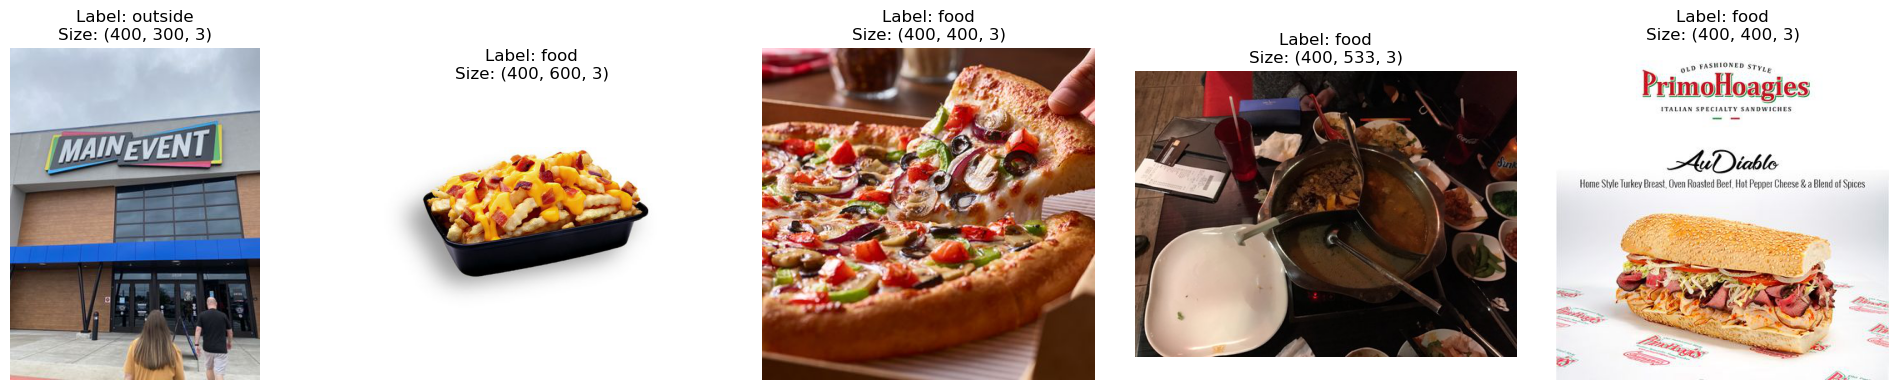

In [13]:
sample_df = df.sample(n=5, random_state=42)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join('images', f"{row['photo_id']}.jpg")
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Label: {row['label']}\nSize: {img.shape}")
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [14]:
def process_images(photo_ids, img_dir, target_size = (64, 64)):
    processed_images = []
    missing_ids = []
    for photo_id in photo_ids:
         # Construct full input path
        image_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            image = Image.open(image_path)
            image_resized = image.resize(target_size)
            image_resized = np.array(image_resized)
            image_normalized = image_resized / 255.0
            processed_images.append(image_normalized)
        except Exception as e:
            missing_ids.append(photo_id)
            print(f"Error processing image {image_path}: {e}")
    print(f"Missing or corrupt images: {len(missing_ids)}")
    return np.array(processed_images), missing_ids

In [15]:
X, missing_ids = process_images(df["photo_id"], "images")

Error processing image images/PFD3ykdI1WVhvZ8IX4PmLQ.jpg: cannot identify image file 'images/PFD3ykdI1WVhvZ8IX4PmLQ.jpg'
Error processing image images/MZj64XNUN6Og178-6XYR6g.jpg: cannot identify image file 'images/MZj64XNUN6Og178-6XYR6g.jpg'
Error processing image images/B7xR9CuhRpP52PoehQHVow.jpg: cannot identify image file 'images/B7xR9CuhRpP52PoehQHVow.jpg'
Error processing image images/AkiGRjaMKHdJyV7bdHsQjw.jpg: cannot identify image file 'images/AkiGRjaMKHdJyV7bdHsQjw.jpg'
Error processing image images/VSekUmmsGZcX7KaPe_hXyw.jpg: cannot identify image file 'images/VSekUmmsGZcX7KaPe_hXyw.jpg'
Error processing image images/rLafN9k3_AF5lZU0cs3LZg.jpg: cannot identify image file 'images/rLafN9k3_AF5lZU0cs3LZg.jpg'
Error processing image images/PjfJoBrEFgDrxiJy8nyatA.jpg: cannot identify image file 'images/PjfJoBrEFgDrxiJy8nyatA.jpg'
Error processing image images/bf3ymV0YgP7B6rEoriaU2w.jpg: cannot identify image file 'images/bf3ymV0YgP7B6rEoriaU2w.jpg'
Error processing image images/kj

In [16]:
X.shape

(19997, 64, 64, 3)

In [17]:
df_filtered = df[~df["photo_id"].isin(missing_ids)].reset_index(drop=True)

In [18]:
df_filtered.shape

(19997, 4)

In [19]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_filtered["label"])

In [20]:
y.shape

(19997,)

In [21]:
def apply_histogram_equalization(images):
    equalized_images = []

    for image in images:
        # Convert from float (0-1) to uint8 (0-255)
        image_uint8 = (image * 255).astype(np.uint8)

        # Convert to grayscale before applying histogram equalization
        gray_image = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)

        # Apply histogram equalization
        equalized_image = cv2.equalizeHist(gray_image)
        equalized_images.append(equalized_image)

    return np.array(equalized_images)

# Apply histogram equalization only if images exist
if X.size > 0:
    equalized_images = apply_histogram_equalization(X)
    print(f"✅ Successfully processed and equalized {len(equalized_images)} images.")
else:
    print("⚠️ No valid images were processed.")

✅ Successfully processed and equalized 19997 images.


In [22]:
# # Optional: Gaussian Blur (Reduce Noise)
def apply_gaussian_blur(images, kernel_size=(5, 5)):
    blurred_images = []

    for image in images:
        # Convert from float (0-1) to uint8 (0-255)
        image_uint8 = (image * 255).astype(np.uint8)

        # Apply Gaussian Blur
        blurred_image = cv2.GaussianBlur(image_uint8, kernel_size, sigmaX=0)
        blurred_images.append(blurred_image)

    return np.array(blurred_images)

# Apply histogram equalization and Gaussian blur if images exist
if X.size > 0:
    equalized_images = apply_histogram_equalization(X)
    blurred_images = apply_gaussian_blur(X)

    print(f"✅ Successfully processed {len(equalized_images)} equalized images.")
    print(f"✅ Successfully processed {len(blurred_images)} blurred images.")
else:
    print("⚠️ No valid images were processed.")

✅ Successfully processed 19997 equalized images.
✅ Successfully processed 19997 blurred images.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
print(f"✅ Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


✅ Training samples: 15997, Testing samples: 4000


In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # Experiment with different k-values
knn.fit(X_train.reshape(len(X_train), -1), y_train)  # Flatten images

# Predict on test set
y_pred = knn.predict(X_test.reshape(len(X_test), -1))

# Evaluate performance
print(f"✅ KNN Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

✅ KNN Accuracy: 0.6600
              precision    recall  f1-score   support

           0       0.29      0.25      0.27       314
           1       0.74      0.83      0.79      2161
           2       0.61      0.54      0.57      1121
           3       0.29      0.06      0.10        33
           4       0.49      0.42      0.45       371

    accuracy                           0.66      4000
   macro avg       0.48      0.42      0.44      4000
weighted avg       0.64      0.66      0.65      4000



In [26]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

# Perform Grid Search
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train.reshape(len(X_train), -1), y_train)

# Best parameters & accuracy
print(f"✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best accuracy: {grid_search.best_score_:.4f}")

✅ Best parameters: {'n_neighbors': 11}
✅ Best accuracy: 0.6876


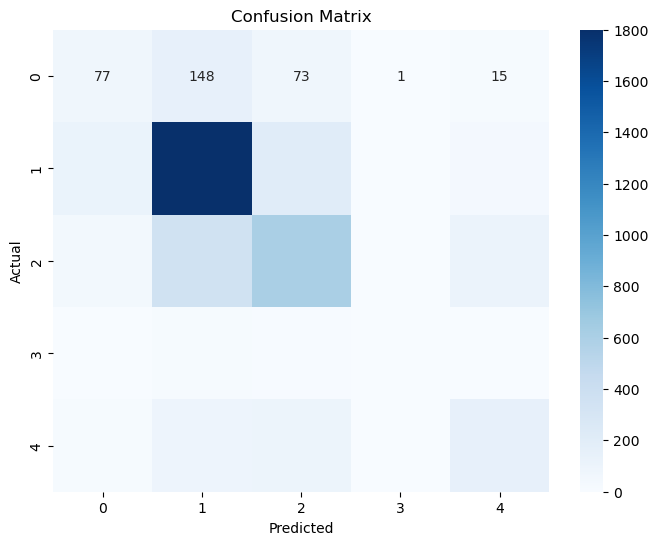

[[  77  148   73    1   15]
 [ 118 1800  206    0   37]
 [  48  356  607    4  106]
 [   3   17   11    2    0]
 [  21   96  100    0  154]]


In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(cm)

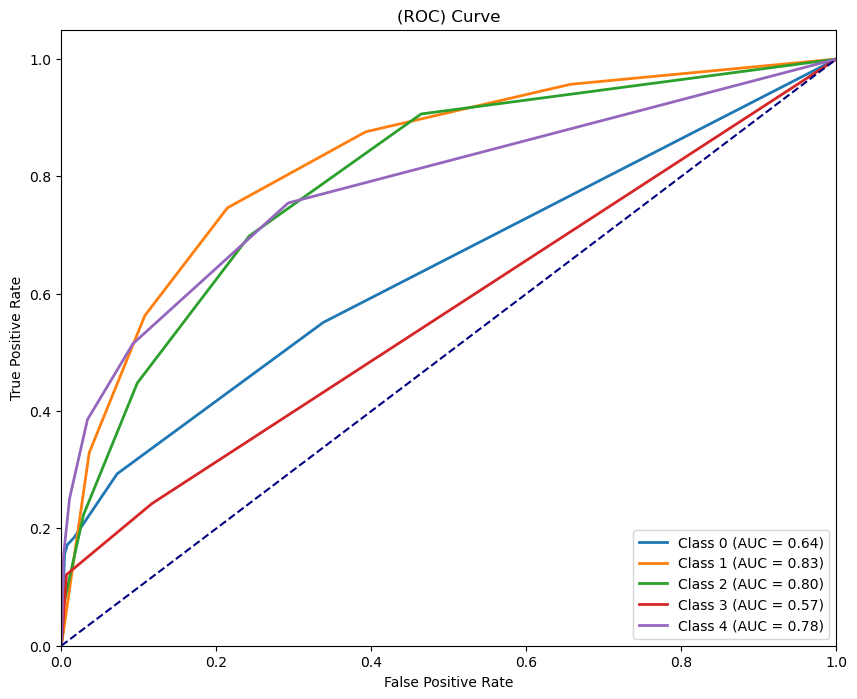

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for each class (One-vs-Rest)
y_prob = knn.predict_proba(X_test.reshape(len(X_test), -1))

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i in range(y_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])  # True labels for class i
    roc_auc = auc(fpr, tpr)  # Calculate AUC for each class
    
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve')
plt.legend(loc='lower right')
plt.show()


## 3. Support Vector Machine (SVM) Model with Confusion Matrix and AUC

In [29]:
# Function to Flatten Images (2D to 1D)
def flatten_images(images):
    return images.reshape(images.shape[0], -1)

# Flatten your image data
X_flattened_train = flatten_images(X_train)

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flattened_train)

In [31]:
from sklearn.svm import SVC

# Initialize SVM model
svm = SVC(kernel="rbf", probability=True, random_state=42, cache_size=2000, gamma="scale")

# Train the model
svm.fit(X_scaled, y_train)

# Predictions and confusion matrix
y_pred_svm = svm.predict(X_test)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# ROC Curve for AUC
y_prob_svm = svm.predict_proba(X_test)[:, 1]  # Probability for positive class
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

ValueError: Found array with dim 4. SVC expected <= 2.

In [33]:
svm.fit(X_scaled, y_train)

ValueError: Found array with dim 4. SVC expected <= 2.

In [36]:
X_flattened_test = flatten_images(X_test)

In [37]:
X_test_scaled = scaler.fit_transform(X_flattened_test)

In [38]:
y_pred_svm = svm.predict(X_test_scaled)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# ROC Curve for AUC
y_prob_svm = svm.predict_proba(X_test)[:, 1]  # Probability for positive class
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

ValueError: Found array with dim 4. SVC expected <= 2.

In [39]:
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]  # Probability for positive class
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

ValueError: multiclass format is not supported

In [40]:
# Plot ROC curve for each class
# y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]  # Probability for positive class
# fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
# roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.figure(figsize=(10, 8))

for i in range(y_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob_svm[:, i])  # True labels for class i
    roc_auc = auc(fpr, tpr)  # Calculate AUC for each class
    
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve')
plt.legend(loc='lower right')
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

<Figure size 1000x800 with 0 Axes>

In [41]:
import joblib

# Save the trained SVM model
joblib.dump(svm, 'svm_model.pkl')
joblib.dump(grid_search, "grid_search.pkl")

# Optionally, save the scaler for feature transformation
joblib.dump(scaler, 'scaler.pkl')

print("SVM model and scaler saved successfully!")

SVM model and scaler saved successfully!


In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix_svm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - SVM')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.show()

In [ ]:
# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_svm, tpr_svm, color='r', lw=2, label=f'ROC curve (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - SVM')
plt.legend(loc='lower right')
plt.show()